# XGBoost – Random Train/Test Split (Non-Spatial CV)

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

import shap

In [2]:
# CONFIG
CITY = "atlanta"
STATE = "13"
COUNTIES = ["121", "089", "067", "135"]

TARGET = "jobs_30min"
RANDOM_STATE = 42

In [3]:
# LOAD PREDICTORS
X_df = pd.read_parquet(
    "../data/processed_predictors/atlanta_2023_predictor_dataset.parquet"
)
print("Predictor shape:", X_df.shape)

# LOAD TARGETS
y_df = pd.read_parquet(
    "../data/processed_job_accessibility/accessibility_state-GA_counties-121-089-067-135_year-2023_thresholds-15-30-45-60.parquet"
)
print("Target shape:", y_df.shape)

Predictor shape: (936, 44)
Target shape: (936, 5)


In [4]:
# MERGE
df = X_df.merge(
    y_df[["from_id", TARGET]],
    left_on="tract_id",
    right_on="from_id",
    how="inner"
)

print("Merged shape:", df.shape)

Merged shape: (936, 46)


In [5]:
# LOAD TRACTS
url = (
    f"https://www2.census.gov/geo/tiger/TIGER2023/"
    f"TRACT/tl_2023_{STATE}_tract.zip"
)

tracts = gpd.read_file(url)

tracts = tracts[tracts["COUNTYFP"].isin(COUNTIES)].copy()

tracts["tract_id"] = tracts["GEOID"].astype(str)

In [6]:
# MERGE GEOMETRY
df = df.merge(
    tracts[["tract_id", "geometry"]],
    on="tract_id",
    how="left"
)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs=tracts.crs)

print("GeoDF shape:", gdf.shape)

GeoDF shape: (936, 47)


In [7]:
# PROJECT
gdf = gdf.to_crs(epsg=5070).copy()

In [8]:
# CENTROIDS (kept but NOT used for splitting)
gdf["centroid"] = gdf.geometry.centroid
gdf["x"] = gdf.centroid.x
gdf["y"] = gdf.centroid.y

# %%
# FEATURES / TARGET
drop_cols = [
    "tract_id",
    "from_id",
    TARGET,
    "geometry",
    "centroid",
    "x",
    "y"
]

feature_cols = [c for c in gdf.columns if c not in drop_cols]

X = gdf[feature_cols]

In [9]:
# CLEAN FEATURES
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# TARGET (log transform)
y = np.log1p(gdf[TARGET])

print("Number of features:", len(feature_cols))

Number of features: 43


In [10]:
# RANDOM TRAIN / TEST SPLIT
train_idx, test_idx = train_test_split(
    gdf.index,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_mask = gdf.index.isin(train_idx)
test_mask = gdf.index.isin(test_idx)

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

y_train_raw = np.expm1(y_train)
y_test_raw = np.expm1(y_test)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 748
Test size: 188


In [11]:
# MODEL
model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    reg_lambda=10,
    objective="reg:squarederror",
    random_state=RANDOM_STATE
)

In [12]:
# TRAIN
model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [13]:
# SHAP EXPLAINER
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

In [14]:
# PREDICT
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

# safety clipping
y_pred = np.nan_to_num(
    y_pred,
    nan=0,
    posinf=y_train_raw.max(),
    neginf=0
)

In [15]:
# METRICS
mae = mean_absolute_error(y_test_raw, y_pred)

rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred))

r2 = r2_score(y_test_raw, y_pred)

print(f"MAE:  {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²:   {r2:.4f}")

MAE:  17,744
RMSE: 35,325
R²:   0.7205


In [16]:
# RESULTS DF
results_df = pd.DataFrame([{
    "mae": mae,
    "rmse": rmse,
    "r2": r2
}])

results_df

,mae,rmse,r2
0,17743.590852,35325.396088,0.720512


In [17]:
# PREDICTIONS
predictions_df = pd.DataFrame({
    "tract_id": gdf.loc[test_mask, "tract_id"],
    "actual": y_test_raw,
    "predicted": y_pred
})

predictions_df.head()

,tract_id,actual,predicted
2,13089021416,51009.0,104060.390625
23,13067030505,19334.0,22839.556641
30,13089021912,1473.0,2086.098145
31,13067030327,6363.0,5223.873047
33,13067031112,22512.0,17900.140625


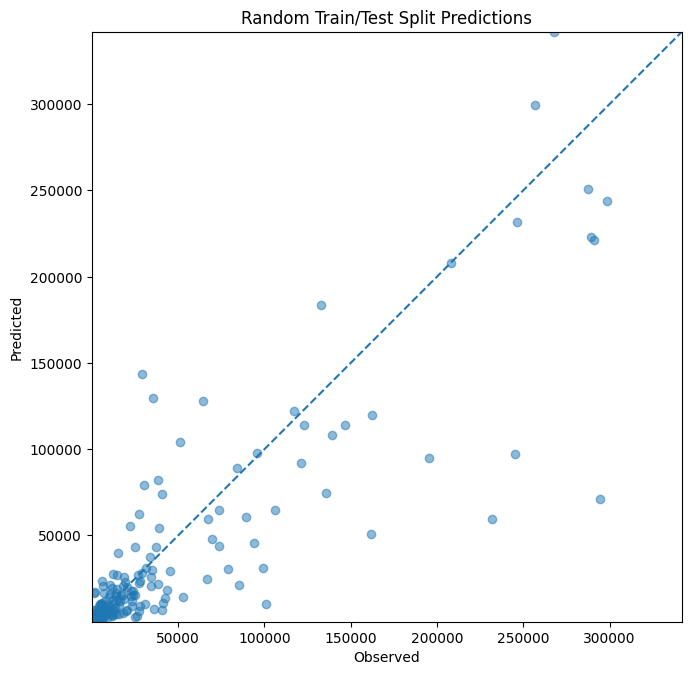

In [18]:
# SCATTER PLOT
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    predictions_df["actual"],
    predictions_df["predicted"],
    alpha=0.5
)

min_val = min(
    predictions_df["actual"].min(),
    predictions_df["predicted"].min()
)

max_val = max(
    predictions_df["actual"].max(),
    predictions_df["predicted"].max()
)

ax.plot([min_val, max_val], [min_val, max_val], "--")

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

ax.set_aspect("equal")

ax.set_xlabel("Observed")
ax.set_ylabel("Predicted")
ax.set_title("Random Train/Test Split Predictions")

plt.tight_layout()
plt.show()

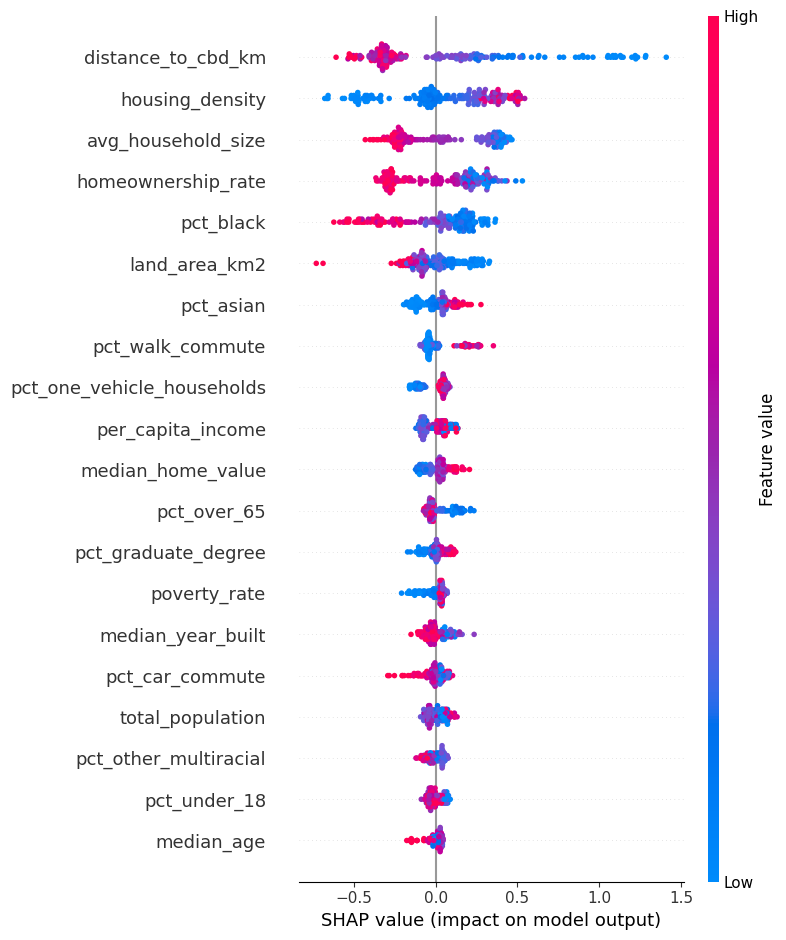

In [19]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_cols,
    show=False
)

plt.tight_layout()
plt.show()

In [20]:
shap_importance = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.head(20)

,feature,mean_abs_shap
37,distance_to_cbd_km,0.402711
34,housing_density,0.258025
7,avg_household_size,0.257140
31,homeownership_rate,0.229411
39,pct_black,0.206060
36,land_area_km2,0.122966
41,pct_asian,0.081110
25,pct_walk_commute,0.072374
20,pct_one_vehicle_households,0.066238
10,per_capita_income,0.063625


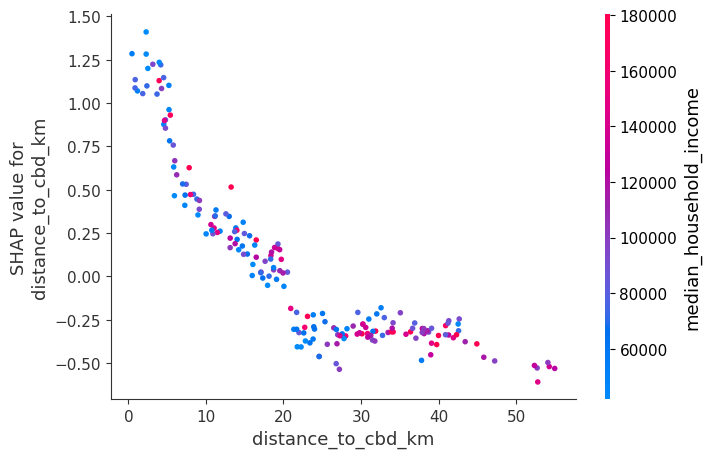

In [21]:
shap.dependence_plot(
    "distance_to_cbd_km",
    shap_values,
    X_test,
    show=True
)

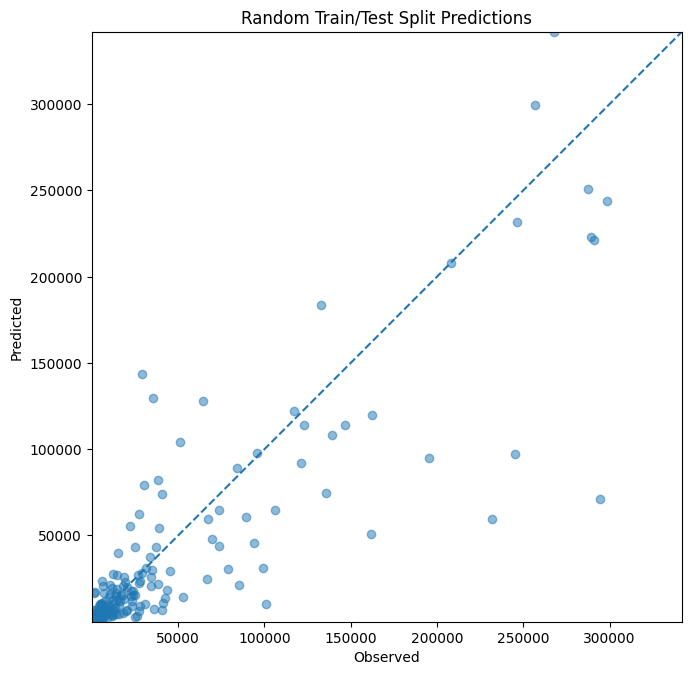

In [23]:
# SCATTER PLOT
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    predictions_df["actual"],
    predictions_df["predicted"],
    alpha=0.5
)

min_val = min(
    predictions_df["actual"].min(),
    predictions_df["predicted"].min()
)

max_val = max(
    predictions_df["actual"].max(),
    predictions_df["predicted"].max()
)

ax.plot([min_val, max_val], [min_val, max_val], "--")

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

ax.set_aspect("equal")

ax.set_xlabel("Observed")
ax.set_ylabel("Predicted")
ax.set_title("Random Train/Test Split Predictions")

plt.tight_layout()
plt.show()